# NFL 2025 — Comparación de Modelos de Predicción

Este notebook compara **8 modelos de regresión** para predecir métricas de juegos NFL:

| # | Modelo | Tipo |
|---|--------|------|
| 1 | Linear Regression | Lineal sin regularización |
| 2 | Ridge | Lineal + regularización L2 |
| 3 | Lasso | Lineal + regularización L1 |
| 4 | ElasticNet | Lineal + L1 + L2 (modelo actual) |
| 5 | Random Forest | Ensemble de árboles (bagging) |
| 6 | Gradient Boosting | Ensemble boosting secuencial |
| 7 | KNN | Vecinos más cercanos |
| 8 | SVR | Máquinas de vectores de soporte |

## Estructura
1. Imports y configuración
2. Conexión a base de datos y carga de datos
3. Análisis Exploratorio (EDA)
4. Feature Engineering
5. Factores Defensivos
6. Creación de matchups (datos de entrenamiento)
7. **Comparación de modelos**
8. **Análisis de resultados y visualizaciones**
9. **Ranking final y selección del mejor modelo**
10. Predicciones con el mejor modelo por métrica

---
## 1. Imports y Configuración

Además de las librerías del sistema original, se añaden:
- `LinearRegression`, `Ridge`, `Lasso` — modelos lineales
- `RandomForestRegressor`, `GradientBoostingRegressor` — ensembles
- `KNeighborsRegressor` — vecinos
- `SVR` — support vector regression
- `cross_val_score`, `Pipeline` — evaluación robusta con CV

In [1]:
from sqlalchemy import create_engine, text
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import pandas as pd
import seaborn as sns
import os
import copy
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)

### Funciones auxiliares

In [2]:
def convert_numpy_types(value):
    if isinstance(value, (np.integer, np.int64, np.int32)):
        return int(value)
    elif isinstance(value, (np.floating, np.float64, np.float32)):
        return float(value)
    elif isinstance(value, np.bool_):
        return bool(value)
    elif isinstance(value, np.ndarray):
        return value.tolist()
    elif pd.isna(value) or value is None:
        return None
    return value

def prepare_db_params(params_dict):
    return {k: convert_numpy_types(v) for k, v in params_dict.items()}

def rank_to_factor(rank, total_teams=32):
    if pd.isna(rank):
        return 0.5
    normalized = (total_teams - rank) / (total_teams - 1)
    return normalized ** 0.8

---
## 2. Conexión a Base de Datos

Se cargan las mismas tres tablas del sistema original:
- **nfl_team_stats**: estadísticas de equipo por semana
- **rankings**: rankings defensivos/ofensivos
- **nfl_schedules**: calendario con resultados

In [3]:
load_dotenv()

DB_NAME = os.getenv("DB_NAME")
DB_HOST = os.getenv("DB_HOST")
DB_PASS = os.getenv("DB_PASS")
DB_PORT = os.getenv("DB_PORT", "5433")
DB_USER = os.getenv("DB_USER")

engine = create_engine(
    f"postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}",
    connect_args={'connect_timeout': 10}
)

with engine.connect() as conn:
    dfT = pd.read_sql(text("SELECT * FROM nfl_team_stats WHERE season >= 2023"), conn)
    dfR = pd.read_sql(text("SELECT * FROM rankings WHERE season >= 2023"), conn)
    dfS = pd.read_sql(text("SELECT * FROM nfl_schedules WHERE season >= 2023"), conn)

current_season = 2025
current_season_data = dfT[dfT['season'] == current_season]
max_available_week = int(current_season_data['week'].max()) if not current_season_data.empty else 0

print(f"nfl_team_stats : {dfT.shape[0]} registros, {dfT.shape[1]} columnas")
print(f"rankings       : {dfR.shape[0]} registros, {dfR.shape[1]} columnas")
print(f"nfl_schedules  : {dfS.shape[0]} registros, {dfS.shape[1]} columnas")
print(f"Temporadas     : {sorted(dfT['season'].unique())}")
print(f"Última semana 2025: {max_available_week}")

nfl_team_stats : 1598 registros, 15 columnas
rankings       : 1344 registros, 22 columnas
nfl_schedules  : 842 registros, 46 columnas
Temporadas     : [2023, 2024, 2025]
Última semana 2025: 17


---
## 3. Análisis Exploratorio de Datos (EDA)

### 3.1 Estructura de nfl_team_stats

In [4]:
print("Columnas:", dfT.columns.tolist())
dfT.head()

Columnas: ['season', 'week', 'game_id', 'team', 'total_yards', 'passing_yards', 'rushing_yards', 'turnovers', 'op_passing_yards', 'op_rushing_yards', 'op_total_yards', 'points', 'op_points', 'opponent', 'location']


,season,week,game_id,team,total_yards,passing_yards,rushing_yards,turnovers,op_passing_yards,op_rushing_yards,op_total_yards,points,op_points,opponent,location
0,2025,6,20251009_PHI@NYG,PHI,339,266,73,2,194,172,366,17,34,NYG,away
1,2025,6,20251009_PHI@NYG,NYG,366,194,172,0,266,73,339,34,17,PHI,home
2,2025,9,20251102_KC@BUF,KC,305,226,79,1,263,141,404,21,28,BUF,away
3,2025,9,20251102_KC@BUF,BUF,404,263,141,0,226,79,305,28,21,KC,home
4,2025,5,20251002_SF@LAR,SF,407,333,74,0,378,78,456,26,23,LAR,away


In [5]:
dfT.describe()

,season,week,total_yards,passing_yards,rushing_yards,turnovers,op_passing_yards,op_rushing_yards,op_total_yards,points,op_points
count,1598.000000,1598.000000,1598.000000,1598.000000,1598.000000,1598.000000,1598.000000,1598.000000,1598.000000,1598.000000,1598.000000
mean,2023.981227,9.319149,332.690238,216.157071,116.533166,1.241552,216.157071,116.533166,332.690238,21.852315,21.852315
std,0.812179,5.199780,84.657362,73.360023,49.908330,1.168026,73.360023,49.908330,84.657362,9.694299,9.694299
min,2023.000000,1.000000,58.000000,-10.000000,15.000000,0.000000,-10.000000,15.000000,58.000000,0.000000,0.000000
25%,2023.000000,5.000000,274.000000,167.000000,79.000000,0.000000,167.000000,79.000000,274.000000,15.000000,15.000000
50%,2024.000000,9.000000,334.000000,212.000000,112.000000,1.000000,212.000000,112.000000,334.000000,21.000000,21.000000
75%,2025.000000,14.000000,389.000000,264.000000,146.000000,2.000000,264.000000,146.000000,389.000000,28.000000,28.000000
max,2025.000000,18.000000,726.000000,477.000000,350.000000,6.000000,477.000000,350.000000,726.000000,70.000000,70.000000


In [6]:
null_counts = dfT.isnull().sum()
print("Valores nulos:", null_counts[null_counts > 0].to_dict() if null_counts.any() else "Ninguno")

Valores nulos: Ninguno


### 3.2 Distribución de puntos por temporada

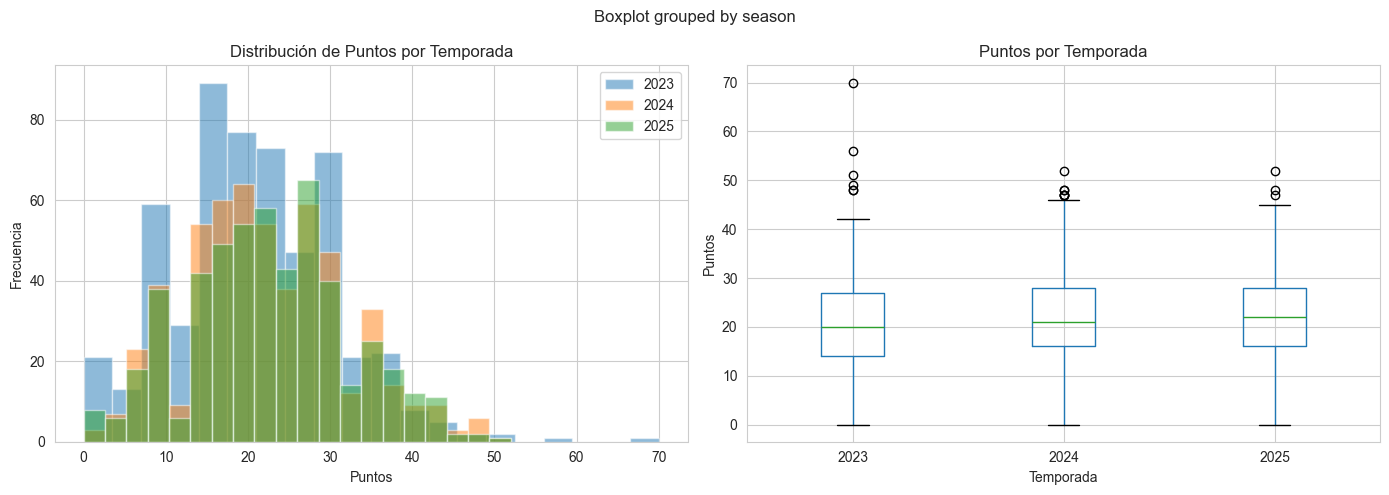

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for season in sorted(dfT['season'].unique()):
    axes[0].hist(dfT[dfT['season'] == season]['points'], alpha=0.5, label=str(season), bins=20)
axes[0].set_xlabel('Puntos')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Puntos por Temporada')
axes[0].legend()

dfT.boxplot(column='points', by='season', ax=axes[1])
axes[1].set_title('Puntos por Temporada')
axes[1].set_xlabel('Temporada')
axes[1].set_ylabel('Puntos')

plt.tight_layout()
plt.show()

### 3.3 Distribución de yardas

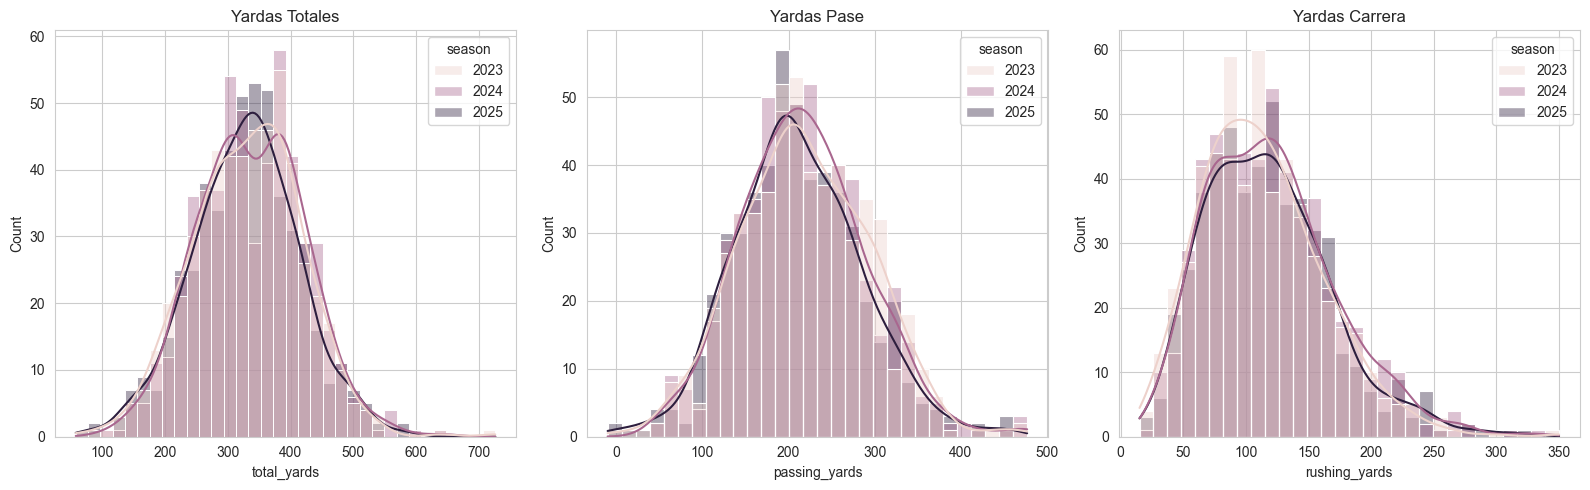

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (metric, title) in zip(axes, [('total_yards','Totales'),('passing_yards','Pase'),('rushing_yards','Carrera')]):
    if metric in dfT.columns:
        sns.histplot(data=dfT, x=metric, hue='season', ax=ax, kde=True, alpha=0.4)
        ax.set_title(f'Yardas {title}')
plt.tight_layout()
plt.show()

### 3.4 Correlación entre métricas ofensivas

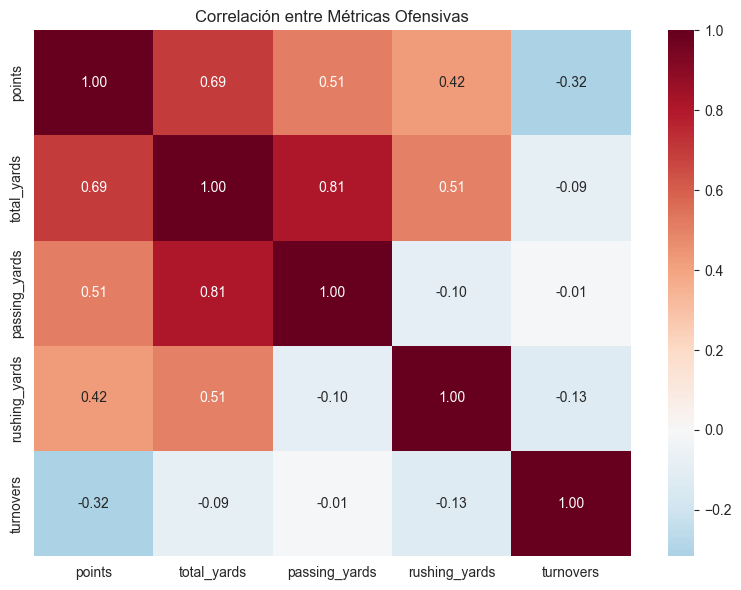

In [9]:
offensive_cols = [c for c in ['points','total_yards','passing_yards','rushing_yards','turnovers'] if c in dfT.columns]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(dfT[offensive_cols].corr(), annot=True, cmap='RdBu_r', center=0, ax=ax, fmt='.2f')
ax.set_title('Correlación entre Métricas Ofensivas')
plt.tight_layout()
plt.show()

### 3.5 Promedio de puntos por equipo (temporada más reciente)

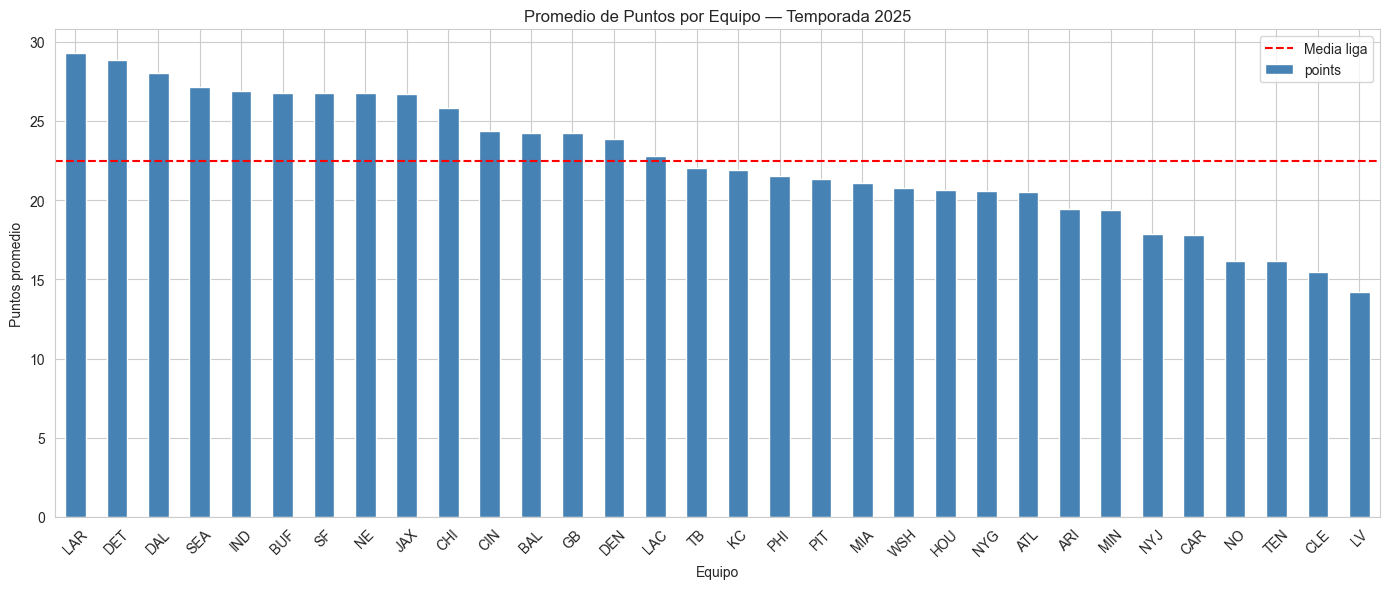

In [10]:
latest_season = dfT['season'].max()
team_avgs = dfT[dfT['season'] == latest_season].groupby('team')[['points','total_yards']].mean().sort_values('points', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
team_avgs['points'].plot(kind='bar', ax=ax, color='steelblue')
ax.axhline(y=team_avgs['points'].mean(), color='red', linestyle='--', label='Media liga')
ax.set_title(f'Promedio de Puntos por Equipo — Temporada {latest_season}')
ax.set_xlabel('Equipo')
ax.set_ylabel('Puntos promedio')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.6 Ventaja de local

In [11]:
games_scored = dfS[(dfS['away_score'].notna()) & (dfS['home_score'].notna())].copy()
games_scored['home_win']   = games_scored['home_score'] > games_scored['away_score']
games_scored['point_diff'] = games_scored['home_score'] - games_scored['away_score']

home_adv = games_scored.groupby('season').agg(
    home_win_pct  = ('home_win',   'mean'),
    avg_point_diff= ('point_diff', 'mean'),
    total_games   = ('home_win',   'count')
).round(3)

print("Ventaja de local por temporada:")
print(home_adv)
print(f"\nVentaja promedio: {games_scored['point_diff'].mean():.2f} pts | % victorias local: {games_scored['home_win'].mean():.1%}")

Ventaja de local por temporada:
        home_win_pct  avg_point_diff  total_games
season                                           
2023           0.565           2.923          285
2024           0.547           2.277          285

Ventaja promedio: 2.60 pts | % victorias local: 55.6%


---
## 4. Feature Engineering

Se crean las mismas features que en `team_model.py`:

| Feature | Descripción |
|---------|-------------|
| `{metric}_avg_{3,4,6}` | Promedios móviles (3, 4, 6 semanas) |
| `{metric}_std_{3,4,6}` | Desviaciones estándar móviles |
| `{metric}_trend_{3,4,6}` | Diferencia entre promedios consecutivos |
| `offensive_efficiency` | Puntos / (total_yards + 1) |
| `pass_rush_ratio` | passing_yards / (rushing_yards + 1) |
| `recent_points_avg` | Promedio de puntos últimas 2 semanas |

In [12]:
dfT_features = dfT.sort_values(['team', 'season', 'week']).copy()

base_metrics = [
    'total_yards', 'passing_yards', 'rushing_yards', 'points',
    'turnovers', 'op_total_yards', 'op_passing_yards', 'op_rushing_yards', 'op_points'
]

for window in [3, 4, 6]:
    for metric in base_metrics:
        if metric not in dfT_features.columns:
            continue
        dfT_features[f'{metric}_avg_{window}'] = (
            dfT_features.groupby(['team', 'season'])[metric]
            .rolling(window=window, min_periods=1).mean()
            .reset_index(level=[0, 1], drop=True)
        )
        dfT_features[f'{metric}_std_{window}'] = (
            dfT_features.groupby(['team', 'season'])[metric]
            .rolling(window=window, min_periods=1).std()
            .reset_index(level=[0, 1], drop=True)
        ).fillna(0)
        dfT_features[f'{metric}_trend_{window}'] = (
            dfT_features.groupby(['team', 'season'])[f'{metric}_avg_{window}']
            .diff(1).fillna(0)
        )

dfT_features['offensive_efficiency'] = dfT_features['points'] / (dfT_features['total_yards'] + 1)
dfT_features['pass_rush_ratio']      = dfT_features['passing_yards'] / (dfT_features['rushing_yards'] + 1)
dfT_features['recent_points_avg']    = (
    dfT_features.groupby(['team', 'season'])['points']
    .rolling(window=2, min_periods=1).mean()
    .reset_index(level=[0, 1], drop=True)
)

print(f"Columnas totales: {len(dfT_features.columns)} ({len(dfT_features.columns) - len(dfT.columns)} nuevas)")

Columnas totales: 99 (84 nuevas)


### 4.1 Visualización de features — equipo ejemplo

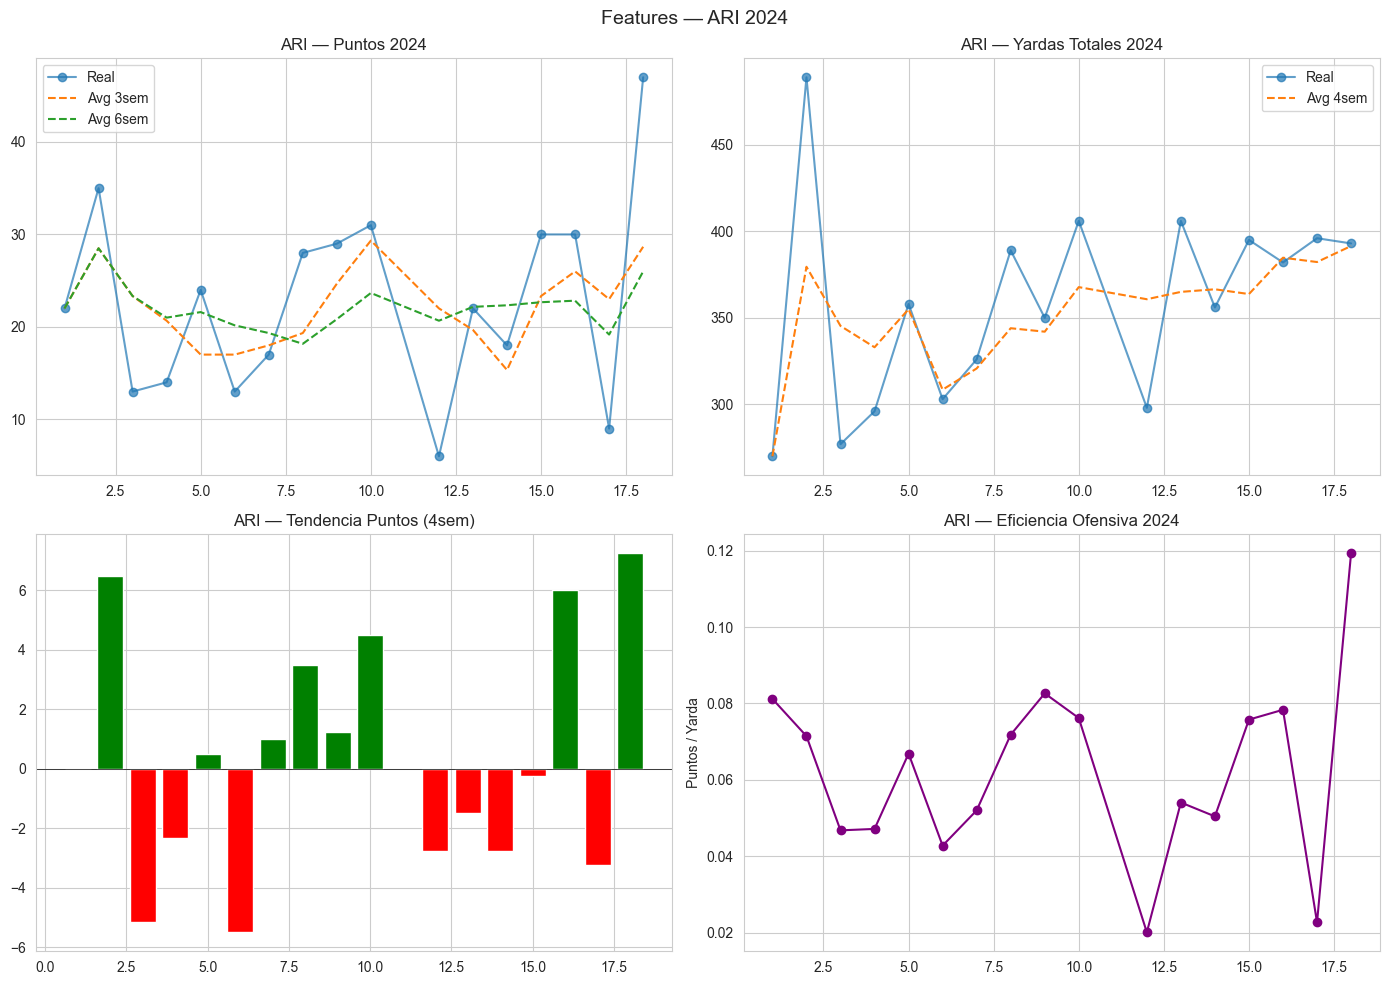

In [13]:
example_team = dfT_features['team'].value_counts().index[0]
team_data    = dfT_features[(dfT_features['team'] == example_team) & (dfT_features['season'] == 2024)]

if not team_data.empty:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0,0].plot(team_data['week'], team_data['points'], 'o-', label='Real', alpha=0.7)
    axes[0,0].plot(team_data['week'], team_data['points_avg_3'], '--', label='Avg 3sem')
    axes[0,0].plot(team_data['week'], team_data['points_avg_6'], '--', label='Avg 6sem')
    axes[0,0].set_title(f'{example_team} — Puntos 2024')
    axes[0,0].legend()

    axes[0,1].plot(team_data['week'], team_data['total_yards'], 'o-', label='Real', alpha=0.7)
    axes[0,1].plot(team_data['week'], team_data['total_yards_avg_4'], '--', label='Avg 4sem')
    axes[0,1].set_title(f'{example_team} — Yardas Totales 2024')
    axes[0,1].legend()

    colors = ['green' if x > 0 else 'red' for x in team_data['points_trend_4']]
    axes[1,0].bar(team_data['week'], team_data['points_trend_4'], color=colors)
    axes[1,0].axhline(y=0, color='black', linewidth=0.5)
    axes[1,0].set_title(f'{example_team} — Tendencia Puntos (4sem)')

    axes[1,1].plot(team_data['week'], team_data['offensive_efficiency'], 'o-', color='purple')
    axes[1,1].set_title(f'{example_team} — Eficiencia Ofensiva 2024')
    axes[1,1].set_ylabel('Puntos / Yarda')

    plt.suptitle(f'Features — {example_team} 2024', fontsize=14)
    plt.tight_layout()
    plt.show()

---
## 5. Factores Defensivos

Los rankings se normalizan a un factor 0–1 con exponencial (^0.8):
- **Factor ≈ 1** → defensa élite (ranking bajo)
- **Factor ≈ 0** → defensa débil (ranking alto)

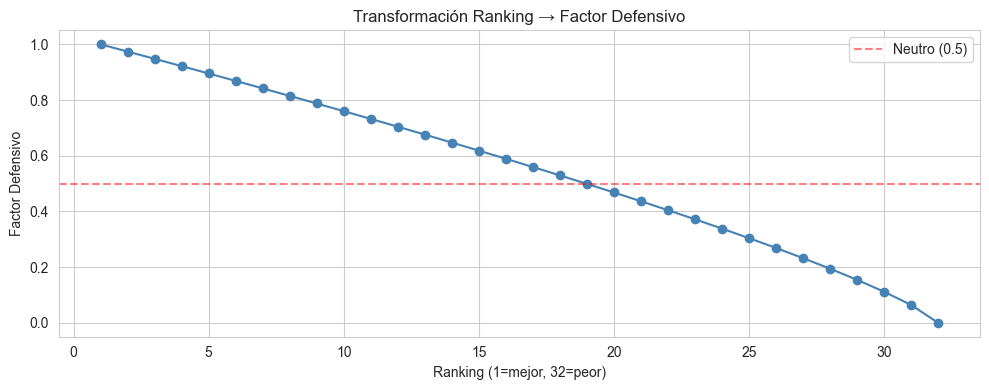

In [14]:
for rank_col, factor_col in [
    ('op_total_yards_rank', 'op_total_yards_factor'),
    ('op_points_rank',      'op_points_factor')
]:
    if rank_col in dfR.columns:
        dfR[factor_col] = dfR[rank_col].apply(rank_to_factor)

# Visualizar la transformación
ranks   = np.arange(1, 33)
factors = [rank_to_factor(r) for r in ranks]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ranks, factors, 'o-', color='steelblue')
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Neutro (0.5)')
ax.set_xlabel('Ranking (1=mejor, 32=peor)')
ax.set_ylabel('Factor Defensivo')
ax.set_title('Transformación Ranking → Factor Defensivo')
ax.legend()
plt.tight_layout()
plt.show()

---
## 6. Creación de Matchups (Datos de Entrenamiento)

Por cada juego histórico con resultado:
1. Se toman las estadísticas del equipo **antes** del juego
2. Se añaden los rankings defensivos del oponente
3. Cada juego genera **2 registros** (local + visitante)

In [15]:
# Estadísticas finales 2024 (fallback para semana 1 de 2025)
team_2024_stats = {}
for team in dfT_features[dfT_features['season'] == 2024]['team'].unique():
    t_data = dfT_features[
        (dfT_features['team'] == team) & (dfT_features['season'] == 2024)
    ].sort_values('week')
    if not t_data.empty:
        team_2024_stats[team] = t_data.tail(1).iloc[0]

print(f"Estadísticas 2024 calculadas para {len(team_2024_stats)} equipos")

Estadísticas 2024 calculadas para 32 equipos


In [16]:
matchups = []
training_games = dfS[
    (dfS['season'] >= 2023) &
    pd.notna(dfS['away_score']) &
    pd.notna(dfS['home_score'])
]
print(f"Juegos de entrenamiento disponibles: {len(training_games)}")

for _, game in training_games.iterrows():
    away_stats = dfT_features[
        (dfT_features['team'] == game['away_team']) &
        (dfT_features['season'] == game['season']) &
        (dfT_features['week'] < game['week'])
    ].tail(1)
    home_stats = dfT_features[
        (dfT_features['team'] == game['home_team']) &
        (dfT_features['season'] == game['season']) &
        (dfT_features['week'] < game['week'])
    ].tail(1)

    if away_stats.empty:
        away_stats = dfT_features[
            (dfT_features['team'] == game['away_team']) &
            (dfT_features['season'] == game['season']) &
            (dfT_features['week'] == game['week'])
        ].head(1)
    if home_stats.empty:
        home_stats = dfT_features[
            (dfT_features['team'] == game['home_team']) &
            (dfT_features['season'] == game['season']) &
            (dfT_features['week'] == game['week'])
        ].head(1)
    if away_stats.empty or home_stats.empty:
        continue

    away_def = dfR[
        (dfR['team'] == game['away_team']) & (dfR['season'] == game['season']) & (dfR['week'] <= game['week'])
    ].tail(1)
    home_def = dfR[
        (dfR['team'] == game['home_team']) & (dfR['season'] == game['season']) & (dfR['week'] <= game['week'])
    ].tail(1)
    if away_def.empty or home_def.empty:
        continue

    away_actual = dfT_features[
        (dfT_features['team'] == game['away_team']) &
        (dfT_features['season'] == game['season']) &
        (dfT_features['week'] == game['week'])
    ]
    home_actual = dfT_features[
        (dfT_features['team'] == game['home_team']) &
        (dfT_features['season'] == game['season']) &
        (dfT_features['week'] == game['week'])
    ]
    if away_actual.empty or home_actual.empty:
        continue

    for team_type in ['away', 'home']:
        is_home    = 1 if team_type == 'home' else 0
        team_stats = (away_stats if team_type == 'away' else home_stats).iloc[0]
        opp_def    = (home_def   if team_type == 'away' else away_def).iloc[0]
        actual_s   = (away_actual if team_type == 'away' else home_actual).iloc[0]
        act_pts    = game['away_score'] if team_type == 'away' else game['home_score']

        matchups.append({
            'season': game['season'], 'week': game['week'], 'is_home': is_home,
            'team_points_avg_3':       team_stats.get('points_avg_3', 24),
            'team_points_avg_4':       team_stats.get('points_avg_4', 24),
            'team_points_avg_6':       team_stats.get('points_avg_6', 24),
            'team_total_yards_avg_3':  team_stats.get('total_yards_avg_3', 350),
            'team_total_yards_avg_4':  team_stats.get('total_yards_avg_4', 350),
            'team_total_yards_avg_6':  team_stats.get('total_yards_avg_6', 350),
            'team_passing_yards_avg_4': team_stats.get('passing_yards_avg_4', 230),
            'team_rushing_yards_avg_4': team_stats.get('rushing_yards_avg_4', 120),
            'team_points_std_4':       team_stats.get('points_std_4', 7),
            'team_total_yards_std_4':  team_stats.get('total_yards_std_4', 50),
            'team_points_trend_4':     team_stats.get('points_trend_4', 0),
            'team_total_yards_trend_4': team_stats.get('total_yards_trend_4', 0),
            'team_off_efficiency':     team_stats.get('offensive_efficiency', 0.07),
            'team_pass_rush_ratio':    team_stats.get('pass_rush_ratio', 2.0),
            'team_recent_points':      team_stats.get('recent_points_avg', 24),
            'opp_def_total_rank':      opp_def.get('op_total_yards_rank', 16),
            'opp_def_passing_rank':    opp_def.get('op_passing_yards_rank', 16),
            'opp_def_rushing_rank':    opp_def.get('op_rushing_yards_rank', 16),
            'opp_def_points_rank':     opp_def.get('op_points_rank', 16),
            'opp_def_total_factor':    opp_def.get('op_total_yards_factor', 0.5),
            'opp_def_points_factor':   opp_def.get('op_points_factor', 0.5),
            'actual_total_yards':      actual_s.get('total_yards', 350),
            'actual_passing_yards':    actual_s.get('passing_yards', 230),
            'actual_rushing_yards':    actual_s.get('rushing_yards', 120),
            'actual_points':           act_pts
        })

matchup_data = pd.DataFrame(matchups)
print(f"\nMatchups creados: {len(matchup_data)} registros, {len(matchup_data.columns)} columnas")

Juegos de entrenamiento disponibles: 570



Matchups creados: 1086 registros, 28 columnas


### 6.1 Distribución de las variables target

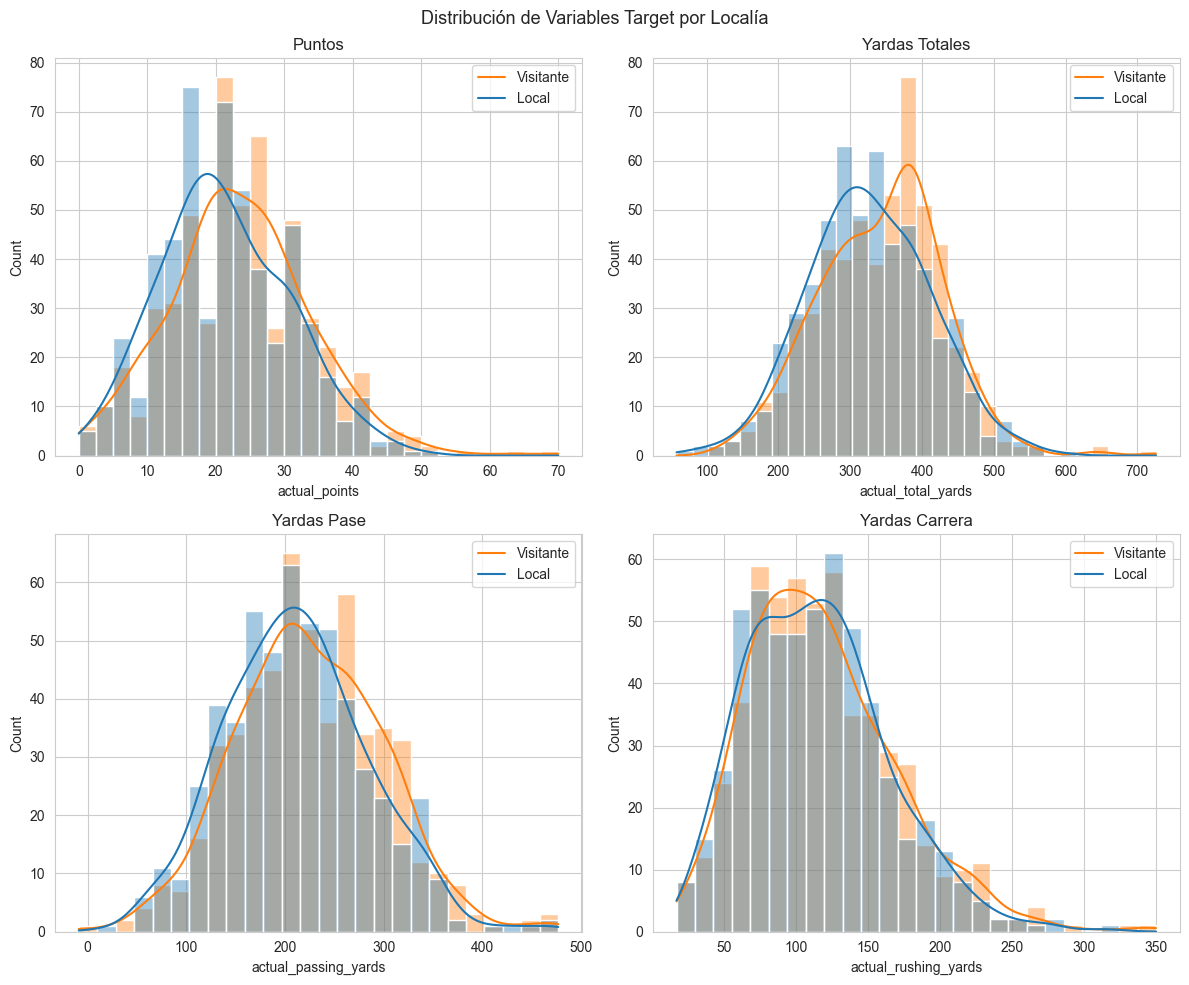

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (col, title) in zip(axes.flat, [
    ('actual_points', 'Puntos'),
    ('actual_total_yards', 'Yardas Totales'),
    ('actual_passing_yards', 'Yardas Pase'),
    ('actual_rushing_yards', 'Yardas Carrera')
]):
    sns.histplot(data=matchup_data, x=col, hue='is_home', ax=ax, kde=True, alpha=0.4)
    ax.set_title(title)
    ax.legend(['Visitante', 'Local'])
plt.suptitle('Distribución de Variables Target por Localía', fontsize=13)
plt.tight_layout()
plt.show()

---
## 7. Comparación de Modelos

### 7.1 Configuración de modelos y features

Se utilizan los mismos 24 features del sistema original. Cada modelo se envuelve en un **Pipeline** con `RobustScaler` para garantizar que la validación cruzada sea libre de data leakage.

In [18]:
METRICS = {
    'total_yards':   'actual_total_yards',
    'passing_yards': 'actual_passing_yards',
    'rushing_yards': 'actual_rushing_yards',
    'points':        'actual_points'
}

FEATURE_COLS = [
    'season', 'week', 'is_home',
    'team_points_avg_3', 'team_points_avg_4', 'team_points_avg_6',
    'team_total_yards_avg_3', 'team_total_yards_avg_4', 'team_total_yards_avg_6',
    'team_passing_yards_avg_4', 'team_rushing_yards_avg_4',
    'team_points_std_4', 'team_total_yards_std_4',
    'team_points_trend_4', 'team_total_yards_trend_4',
    'team_off_efficiency', 'team_pass_rush_ratio', 'team_recent_points',
    'opp_def_total_rank', 'opp_def_passing_rank',
    'opp_def_rushing_rank', 'opp_def_points_rank',
    'opp_def_total_factor', 'opp_def_points_factor'
]

MODEL_CONFIGS = {
    'Linear Regression': LinearRegression(),
    'Ridge':             Ridge(alpha=1.0),
    'Lasso':             Lasso(alpha=0.1, random_state=42),
    'ElasticNet':        ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'KNN':               KNeighborsRegressor(n_neighbors=5),
    'SVR':               SVR(kernel='rbf', C=1.0, epsilon=0.1)
}

print(f"Features: {len(FEATURE_COLS)} | Modelos a comparar: {len(MODEL_CONFIGS)}")
for name in MODEL_CONFIGS:
    print(f"  - {name}")

Features: 24 | Modelos a comparar: 8
  - Linear Regression
  - Ridge
  - Lasso
  - ElasticNet
  - Random Forest
  - Gradient Boosting
  - KNN
  - SVR


### 7.2 Entrenamiento y evaluación

Para cada combinación modelo × métrica:
- **Train/test split 80/20** estratificado por localía
- **Métricas**: MAE, RMSE, R²
- **5-fold cross-validation** con Pipeline (evita data leakage)

In [19]:
comparison_results = {}
trained_models     = {}
test_preds_store   = {}

for metric_name, target_col in METRICS.items():
    print(f"\n{'═'*62}")
    print(f"  {metric_name.upper()}")
    print(f"{'═'*62}")
    print(f"  {'Modelo':<22} {'MAE':>7} {'RMSE':>7} {'R²':>7} {'CV-MAE':>12}")
    print(f"  {'─'*22} {'─'*7} {'─'*7} {'─'*7} {'─'*12}")

    df_clean = matchup_data.dropna(subset=[target_col] + FEATURE_COLS)
    X = df_clean[FEATURE_COLS]
    y = df_clean[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=df_clean['is_home']
    )

    comparison_results[metric_name] = {}
    trained_models[metric_name]     = {}
    test_preds_store[metric_name]   = {'y_test': y_test}

    for model_name, model_template in MODEL_CONFIGS.items():
        model  = copy.deepcopy(model_template)
        scaler = RobustScaler()

        X_train_s = scaler.fit_transform(X_train)
        X_test_s  = scaler.transform(X_test)

        model.fit(X_train_s, y_train)
        y_pred = model.predict(X_test_s)

        pipe = Pipeline([('scaler', RobustScaler()), ('model', copy.deepcopy(model_template))])
        cv_scores = cross_val_score(pipe, X, y, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
        cv_mae = -cv_scores.mean()
        cv_std =  cv_scores.std()

        mae  = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2   = r2_score(y_test, y_pred)

        comparison_results[metric_name][model_name] = {
            'mae': mae, 'rmse': rmse, 'r2': r2, 'cv_mae': cv_mae, 'cv_std': cv_std
        }
        trained_models[metric_name][model_name]   = (model, scaler)
        test_preds_store[metric_name][model_name] = y_pred

        print(f"  {model_name:<22} {mae:7.2f} {rmse:7.2f} {r2:7.3f} {cv_mae:7.2f}±{cv_std:.2f}")


══════════════════════════════════════════════════════════════
  TOTAL_YARDS
══════════════════════════════════════════════════════════════
  Modelo                     MAE    RMSE      R²       CV-MAE
  ────────────────────── ─────── ─────── ─────── ────────────


  Linear Regression        45.51   56.59   0.512   49.72±3.06
  Ridge                    45.39   56.40   0.516   49.63±3.07


  Lasso                    45.44   56.50   0.514   49.56±3.10
  ElasticNet               45.28   56.60   0.512   49.43±3.17


  Random Forest            47.02   58.22   0.484   50.45±2.68


  Gradient Boosting        45.25   58.00   0.488   49.98±2.65


...

  ElasticNet                5.76    7.04   0.386    6.00±0.37


  Random Forest             5.95    7.29   0.343    6.15±0.39


  Gradient Boosting         5.93    7.26   0.348    6.15±0.37


  KNN                       6.03    7.67   0.271    6.73±0.28


  SVR                       6.02    7.44   0.315    6.40±0.41


---
## 8. Análisis de Resultados y Visualizaciones

### 8.1 Tablas comparativas ordenadas por MAE

In [20]:
for metric_name in METRICS:
    comp_df = pd.DataFrame(comparison_results[metric_name]).T.round(3)
    comp_df = comp_df.sort_values('mae')
    comp_df.index.name = 'Modelo'
    print(f"\n{'─'*50}")
    print(f"  {metric_name.upper()}")
    print(f"{'─'*50}")
    display(comp_df)


──────────────────────────────────────────────────
  TOTAL_YARDS
──────────────────────────────────────────────────


,mae,rmse,r2,cv_mae,cv_std
Modelo,,,,,
Gradient Boosting,45.251,58.000,0.488,49.979,2.649
ElasticNet,45.280,56.599,0.512,49.434,3.172
Ridge,45.390,56.400,0.516,49.626,3.066
Lasso,45.443,56.504,0.514,49.564,3.103
Linear Regression,45.513,56.590,0.512,49.724,3.057
Random Forest,47.018,58.223,0.484,50.455,2.679
KNN,53.600,67.026,0.316,55.774,2.840
SVR,57.823,73.967,0.167,60.452,2.979



──────────────────────────────────────────────────
  PASSING_YARDS
──────────────────────────────────────────────────


,mae,rmse,r2,cv_mae,cv_std
Modelo,,,,,
ElasticNet,40.201,51.541,0.397,44.223,2.217
Lasso,40.449,52.053,0.385,44.156,2.434
Ridge,40.539,52.193,0.382,44.168,2.433
Linear Regression,40.839,52.472,0.375,44.200,2.438
Random Forest,43.662,54.620,0.323,45.644,2.390
Gradient Boosting,44.331,55.524,0.300,45.124,2.421
KNN,48.760,60.938,0.157,51.798,1.449
SVR,48.927,62.313,0.119,53.613,1.329



──────────────────────────────────────────────────
  RUSHING_YARDS
──────────────────────────────────────────────────


,mae,rmse,r2,cv_mae,cv_std
Modelo,,,,,
Linear Regression,27.248,35.169,0.480,28.513,0.632
Ridge,27.270,35.184,0.480,28.489,0.607
Lasso,27.288,35.133,0.481,28.375,0.603
ElasticNet,27.501,35.169,0.480,28.479,0.731
Random Forest,28.048,36.430,0.442,28.559,1.079
Gradient Boosting,28.573,37.291,0.415,29.219,1.003
KNN,33.198,42.227,0.250,33.916,2.076
SVR,34.722,44.040,0.185,35.357,1.087



──────────────────────────────────────────────────
  POINTS
──────────────────────────────────────────────────


,mae,rmse,r2,cv_mae,cv_std
Modelo,,,,,
ElasticNet,5.756,7.042,0.386,5.999,0.371
Lasso,5.775,7.033,0.388,5.976,0.360
Linear Regression,5.864,7.199,0.359,6.031,0.350
Ridge,5.878,7.204,0.358,6.018,0.369
Gradient Boosting,5.928,7.260,0.348,6.147,0.367
Random Forest,5.950,7.287,0.343,6.145,0.389
SVR,6.018,7.438,0.315,6.405,0.409
KNN,6.030,7.674,0.271,6.730,0.281


### 8.2 Comparación de MAE por modelo y métrica

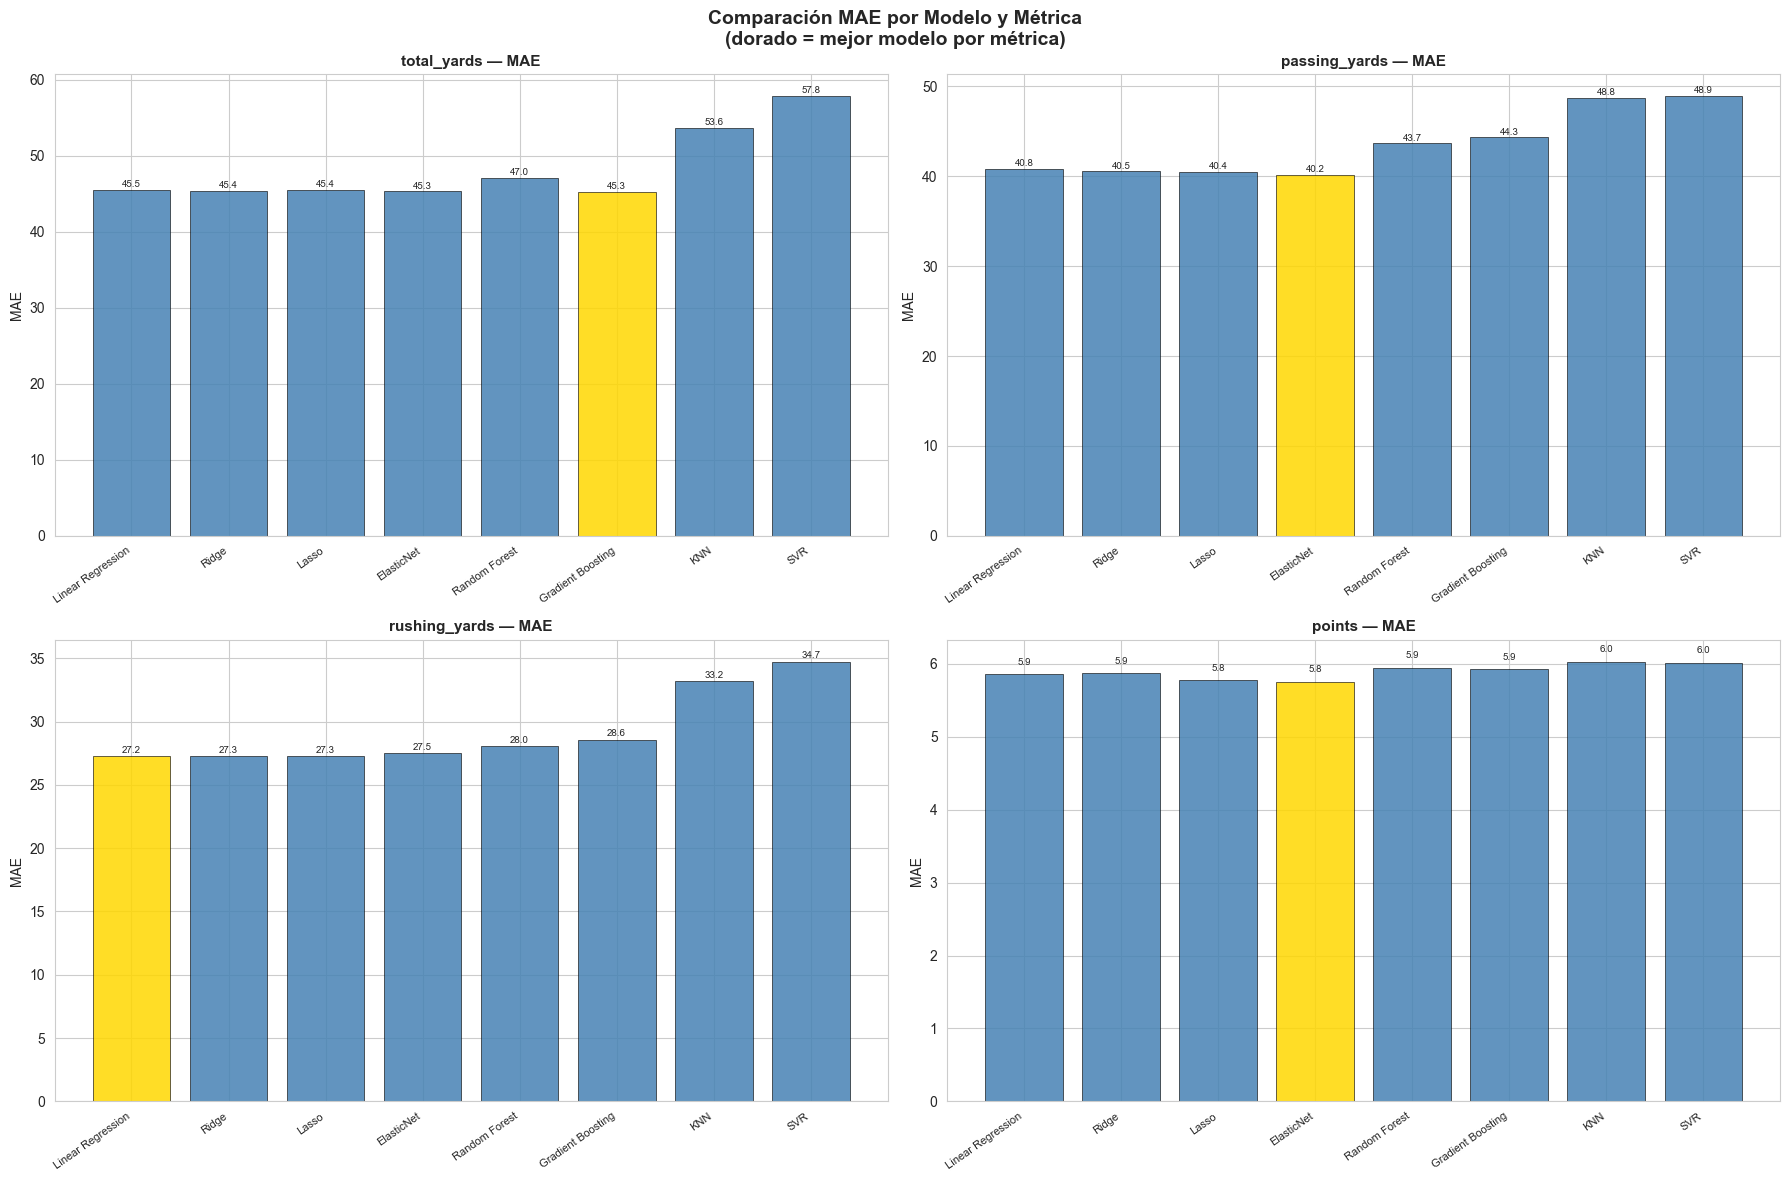

In [21]:
models_list  = list(MODEL_CONFIGS.keys())
metrics_list = list(METRICS.keys())

# Selección provisional del mejor modelo (necesaria para el coloreado)
best_models_temp = {
    m: min(comparison_results[m], key=lambda x: comparison_results[m][x]['mae'])
    for m in metrics_list
}

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
for ax, metric_name in zip(axes.flat, metrics_list):
    maes   = [comparison_results[metric_name][m]['mae'] for m in models_list]
    colors = ['gold' if m == best_models_temp[metric_name] else 'steelblue' for m in models_list]
    bars   = ax.bar(models_list, maes, color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.set_title(f'{metric_name} — MAE', fontsize=11, fontweight='bold')
    ax.set_ylabel('MAE')
    ax.set_xticks(range(len(models_list)))
    ax.set_xticklabels(models_list, rotation=35, ha='right', fontsize=8)
    for bar, val in zip(bars, maes):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.1f}', ha='center', va='bottom', fontsize=7)
plt.suptitle('Comparación MAE por Modelo y Métrica\n(dorado = mejor modelo por métrica)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.3 Comparación de R² por modelo y métrica

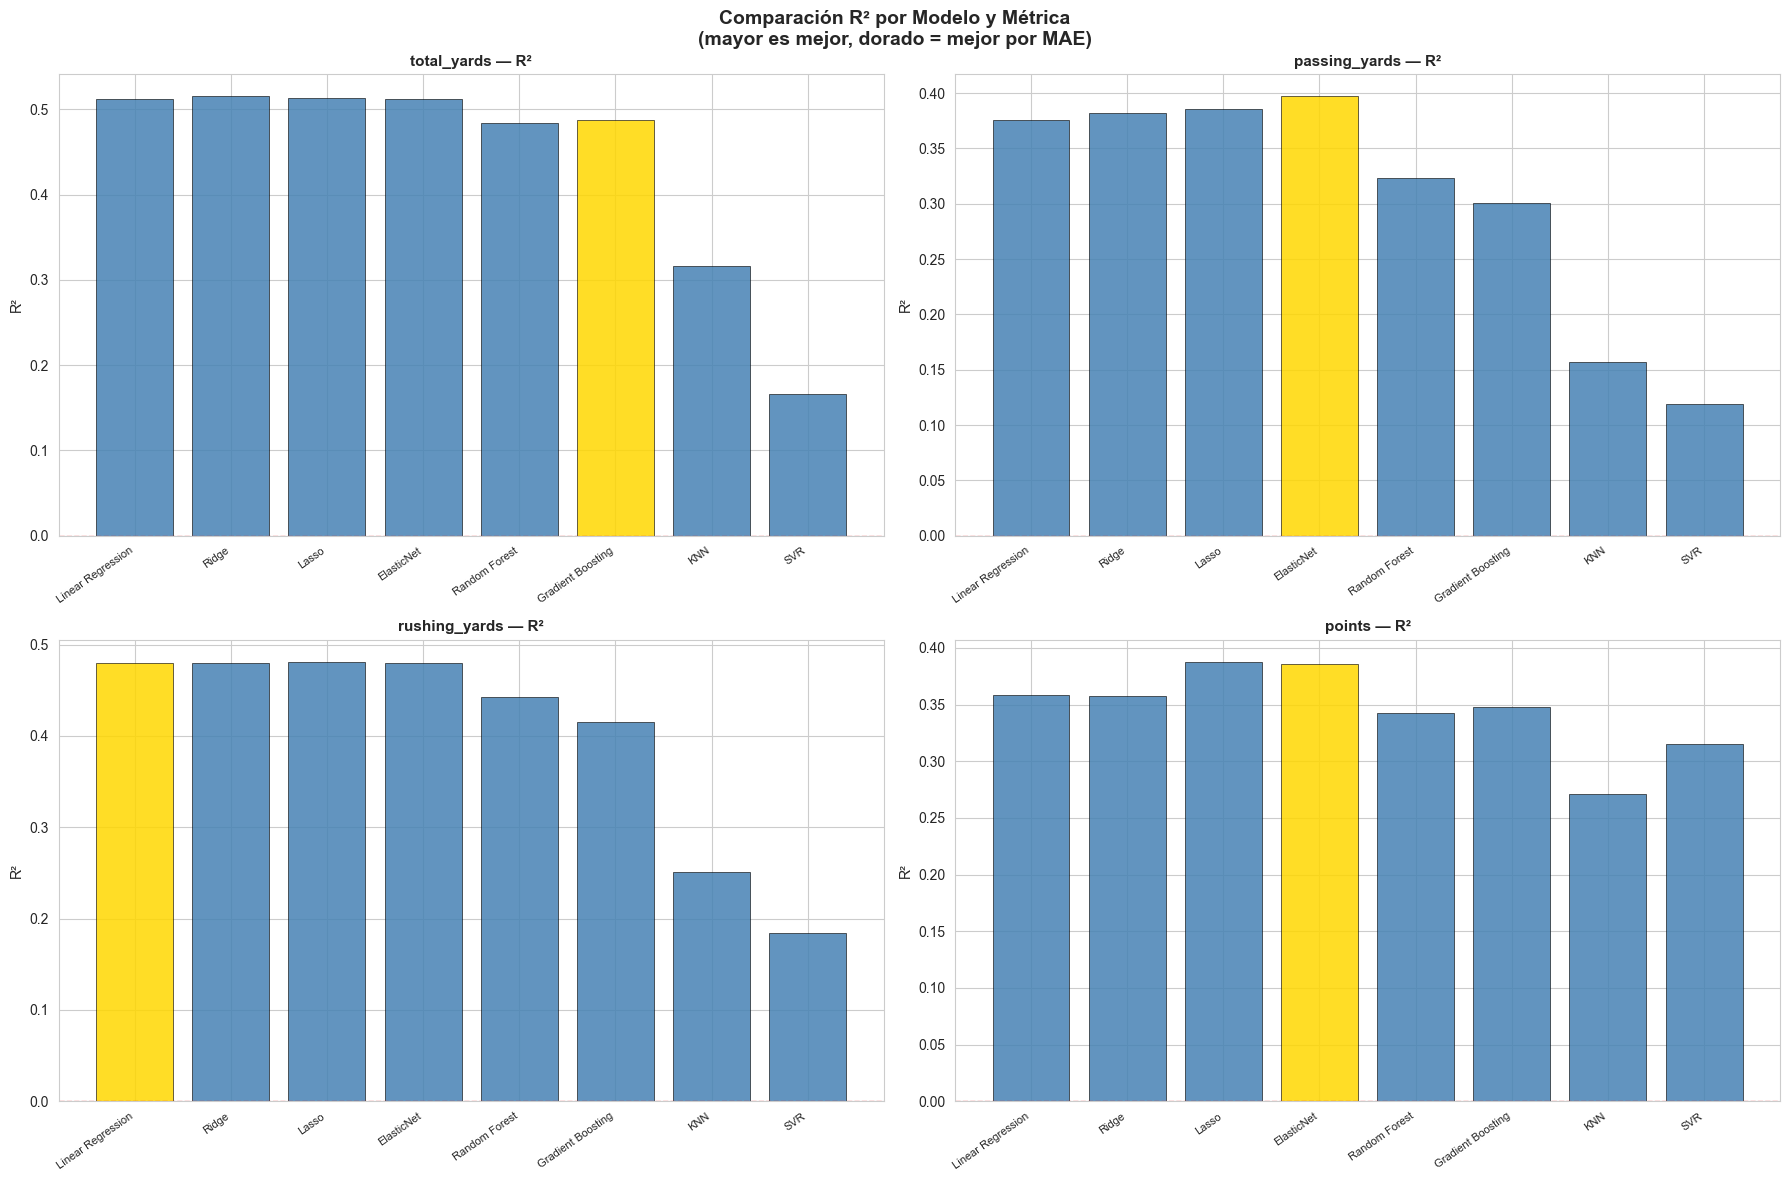

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
for ax, metric_name in zip(axes.flat, metrics_list):
    r2s    = [comparison_results[metric_name][m]['r2'] for m in models_list]
    colors = ['gold' if m == best_models_temp[metric_name] else 'steelblue' for m in models_list]
    ax.bar(models_list, r2s, color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.set_title(f'{metric_name} — R²', fontsize=11, fontweight='bold')
    ax.set_ylabel('R²')
    ax.set_xticks(range(len(models_list)))
    ax.set_xticklabels(models_list, rotation=35, ha='right', fontsize=8)
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, linewidth=1)
plt.suptitle('Comparación R² por Modelo y Métrica\n(mayor es mejor, dorado = mejor por MAE)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.4 Heatmap de Cross-Validation MAE (5-fold)

Este heatmap es clave: muestra la **generalización real** de cada modelo.
Un modelo con MAE bajo en test pero CV-MAE alto puede estar sobre-ajustando.

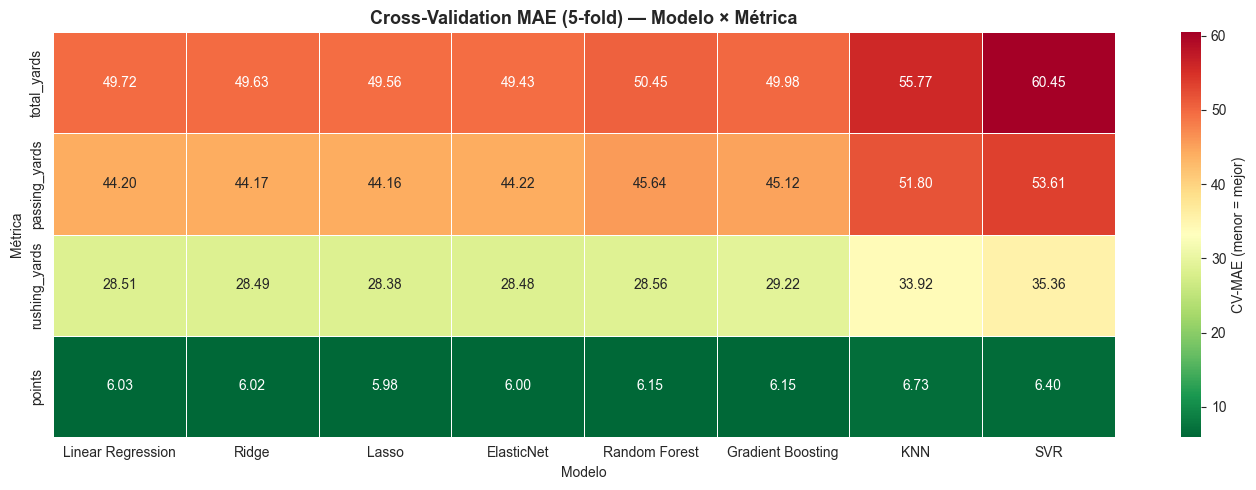

In [23]:
cv_df = pd.DataFrame({
    metric: {m: comparison_results[metric][m]['cv_mae'] for m in models_list}
    for metric in metrics_list
}).T

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(cv_df, annot=True, fmt='.2f', cmap='RdYlGn_r', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'CV-MAE (menor = mejor)'})
ax.set_title('Cross-Validation MAE (5-fold) — Modelo × Métrica',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Modelo')
ax.set_ylabel('Métrica')
plt.tight_layout()
plt.show()

### 8.5 Predicciones vs Valores Reales (mejor modelo por métrica)

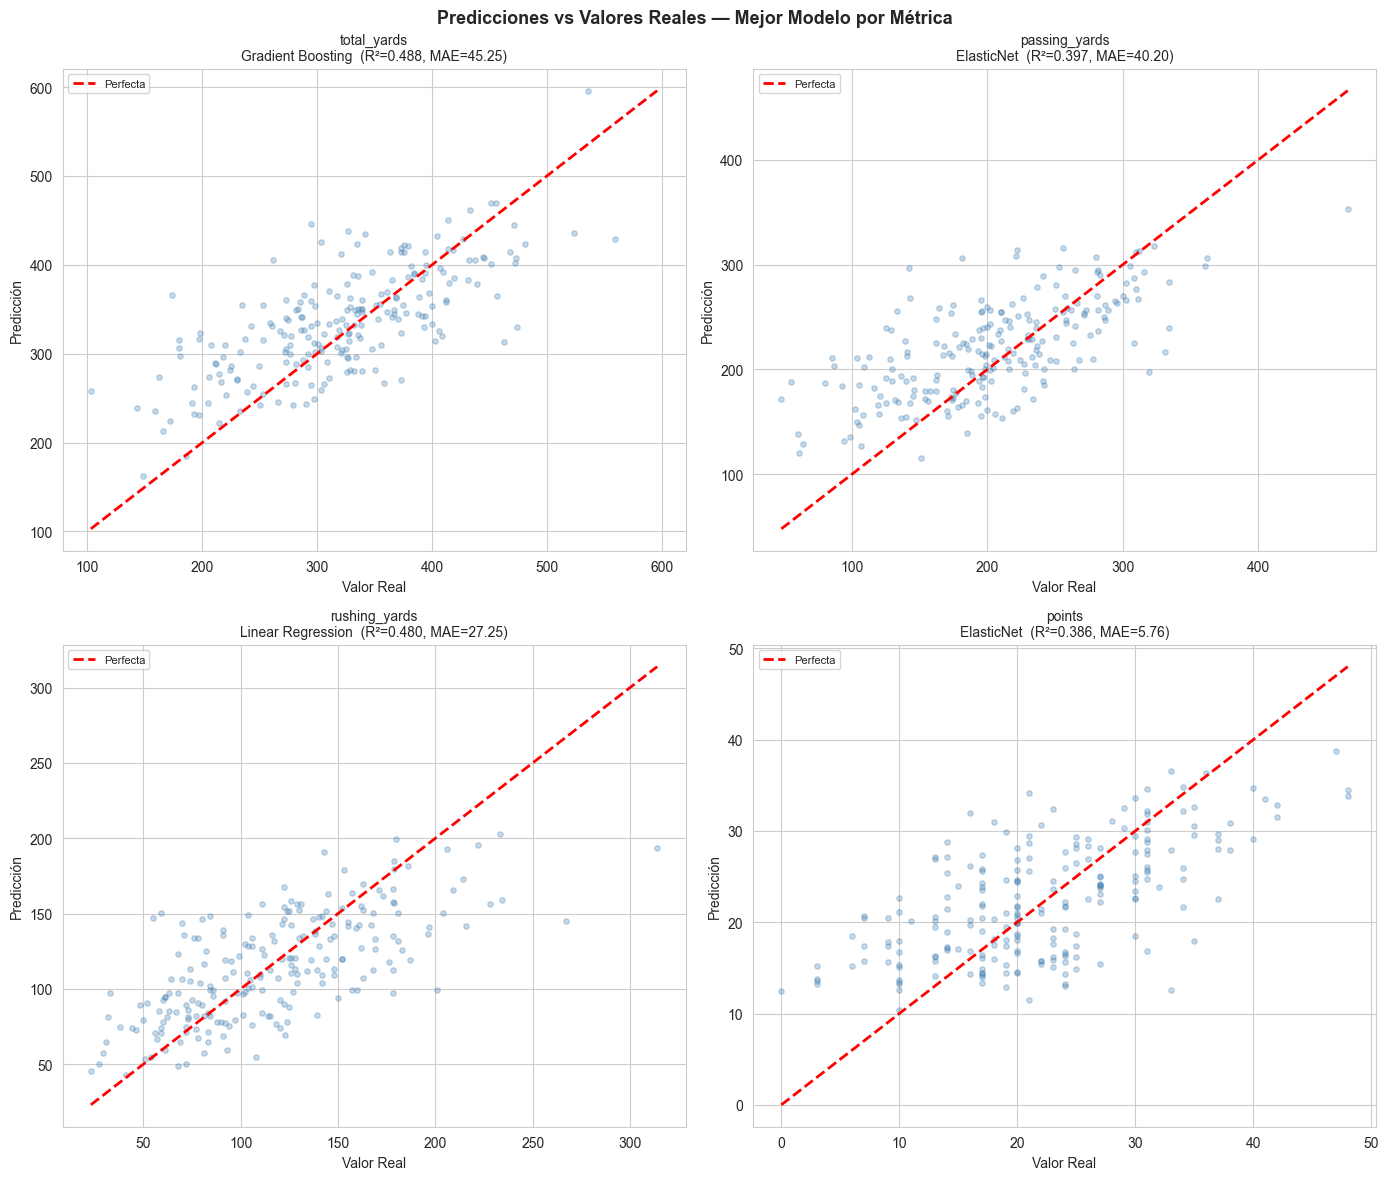

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, metric_name in zip(axes.flat, metrics_list):
    best_name = best_models_temp[metric_name]
    y_test    = test_preds_store[metric_name]['y_test']
    y_pred    = test_preds_store[metric_name][best_name]

    ax.scatter(y_test, y_pred, alpha=0.3, s=15, color='steelblue')
    lo, hi = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=2, label='Perfecta')
    r2  = comparison_results[metric_name][best_name]['r2']
    mae = comparison_results[metric_name][best_name]['mae']
    ax.set_title(f'{metric_name}\n{best_name}  (R²={r2:.3f}, MAE={mae:.2f})', fontsize=10)
    ax.set_xlabel('Valor Real')
    ax.set_ylabel('Predicción')
    ax.legend(fontsize=8)
plt.suptitle('Predicciones vs Valores Reales — Mejor Modelo por Métrica',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.6 Distribución de residuos — ElasticNet vs mejor alternativo

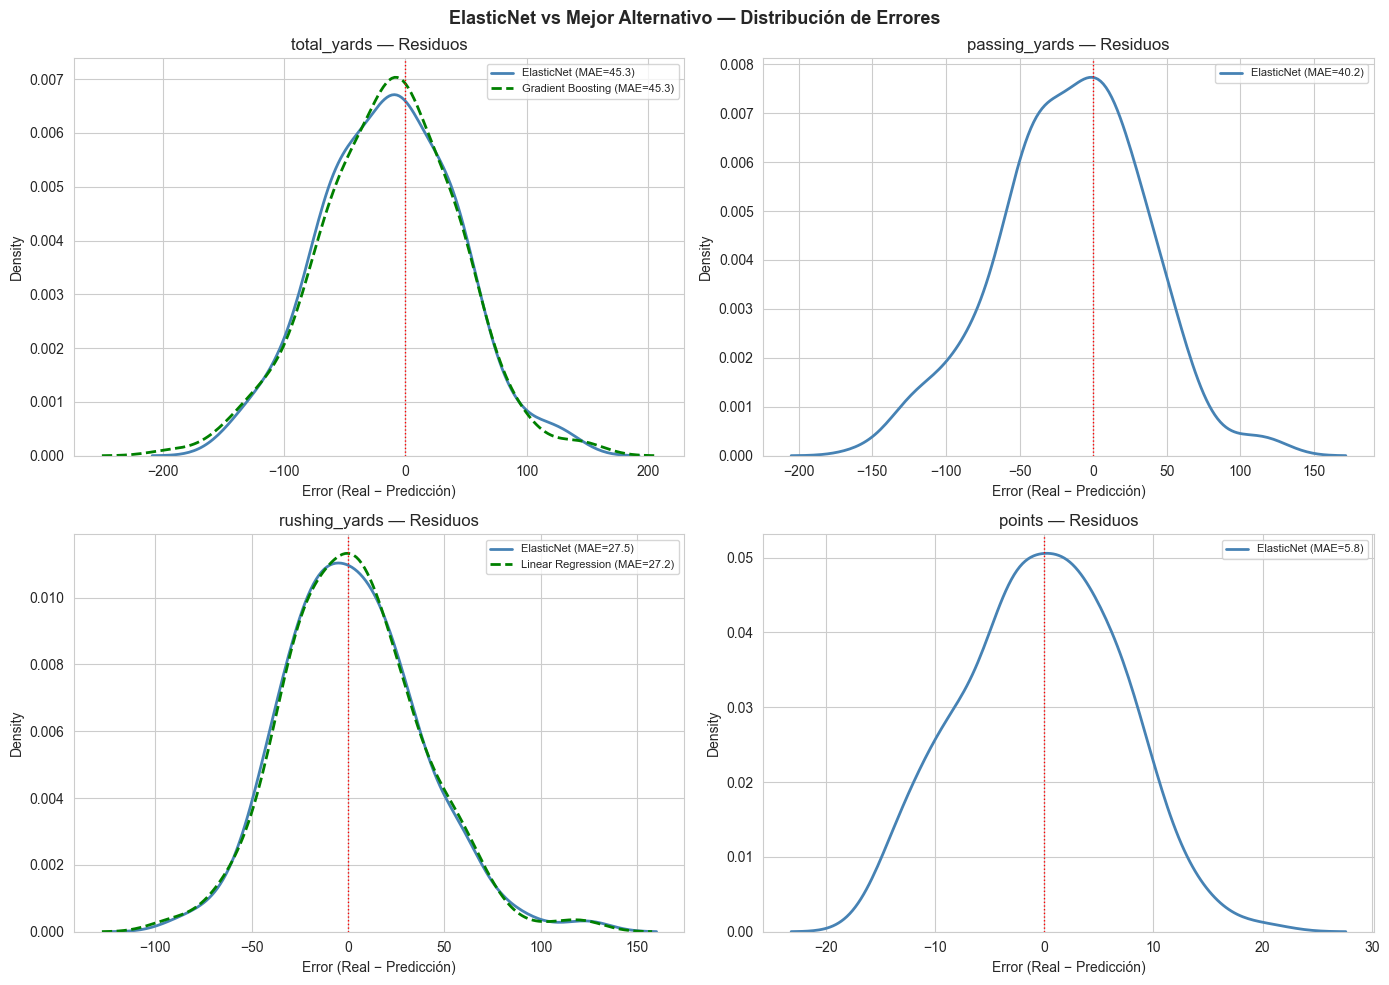

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, metric_name in zip(axes.flat, metrics_list):
    y_test    = test_preds_store[metric_name]['y_test'].values
    en_pred   = test_preds_store[metric_name]['ElasticNet']
    best_name = best_models_temp[metric_name]
    best_pred = test_preds_store[metric_name][best_name]

    en_res   = y_test - en_pred
    best_res = y_test - best_pred

    sns.kdeplot(en_res, ax=ax, color='steelblue', linewidth=2,
                label=f'ElasticNet (MAE={np.abs(en_res).mean():.1f})')
    if best_name != 'ElasticNet':
        sns.kdeplot(best_res, ax=ax, color='green', linewidth=2, linestyle='--',
                    label=f'{best_name} (MAE={np.abs(best_res).mean():.1f})')
    ax.axvline(x=0, color='red', linestyle=':', linewidth=1)
    ax.set_title(f'{metric_name} — Residuos')
    ax.set_xlabel('Error (Real − Predicción)')
    ax.legend(fontsize=8)
plt.suptitle('ElasticNet vs Mejor Alternativo — Distribución de Errores',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.7 Análisis de error por localía (todos los modelos)

In [26]:
print(f"{'Métrica':<15} {'Modelo':<22} {'MAE Local':>10} {'MAE Visit':>10} {'Diff':>7}")
print('─' * 70)

for metric_name, target_col in METRICS.items():
    df_clean = matchup_data.dropna(subset=[target_col] + FEATURE_COLS)
    X_all = df_clean[FEATURE_COLS]
    y_all = df_clean[target_col]
    is_home_all = df_clean['is_home'].values

    for model_name in models_list:
        model, scaler = trained_models[metric_name][model_name]
        y_pred_all    = model.predict(scaler.transform(X_all))
        errors        = np.abs(y_all.values - y_pred_all)
        home_mae  = errors[is_home_all == 1].mean()
        away_mae  = errors[is_home_all == 0].mean()
        print(f"{metric_name:<15} {model_name:<22} {home_mae:10.2f} {away_mae:10.2f} {abs(home_mae-away_mae):7.2f}")
    print()

Métrica         Modelo                  MAE Local  MAE Visit    Diff
──────────────────────────────────────────────────────────────────────
total_yards     Linear Regression           49.75      47.40    2.34
total_yards     Ridge                       49.65      47.35    2.30
total_yards     Lasso                       49.67      47.46    2.21
total_yards     ElasticNet                  49.49      47.85    1.64
total_yards     Random Forest               24.03      25.06    1.03
total_yards     Gradient Boosting           36.74      37.32    0.57
total_yards     KNN                         49.07      49.35    0.28


total_yards     SVR                         59.23      60.16    0.93

passing_yards   Linear Regression           43.64      42.47    1.17
passing_yards   Ridge                       43.54      42.51    1.03
passing_yards   Lasso                       43.57      42.57    1.00
passing_yards   ElasticNet                  43.88      42.77    1.11
passing_yards   Random Forest               22.35      22.58    0.23
passing_yards   Gradient Boosting           33.23      33.83    0.60
passing_yards   KNN                         45.19      43.95    1.25


passing_yards   SVR                         54.19      52.02    2.18

rushing_yards   Linear Regression           26.67      28.89    2.22
rushing_yards   Ridge                       26.72      28.87    2.15
rushing_yards   Lasso                       26.78      28.91    2.13
rushing_yards   ElasticNet                  27.11      28.96    1.85
rushing_yards   Random Forest               13.84      14.87    1.02
rushing_yards   Gradient Boosting           20.51      22.69    2.18
rushing_yards   KNN                         28.79      30.13    1.34


rushing_yards   SVR                         34.94      34.50    0.43

points          Linear Regression            6.21       5.56    0.65
points          Ridge                        6.21       5.56    0.66
points          Lasso                        6.24       5.59    0.65
points          ElasticNet                   6.23       5.60    0.63
points          Random Forest                3.16       2.92    0.23
points          Gradient Boosting            4.81       4.49    0.32
points          KNN                          5.91       5.53    0.37


points          SVR                          6.34       5.71    0.63



---
## 9. Ranking Final y Selección del Mejor Modelo

Se calcula el **rango promedio** de cada modelo en las 4 métricas (menor MAE = rango 1).
Esto permite identificar el modelo más consistente globalmente.

In [27]:
rank_df = pd.DataFrame({
    metric: pd.Series({m: comparison_results[metric][m]['mae'] for m in models_list}).rank()
    for metric in metrics_list
})
rank_df['avg_rank'] = rank_df.mean(axis=1)
rank_df = rank_df.sort_values('avg_rank')

print("RANKING FINAL (menor rango promedio = mejor modelo global)")
print("=" * 60)
display(rank_df.round(2))

RANKING FINAL (menor rango promedio = mejor modelo global)


,total_yards,passing_yards,rushing_yards,points,avg_rank
ElasticNet,2.0,1.0,4.0,1.0,2.00
Lasso,4.0,2.0,3.0,2.0,2.75
Ridge,3.0,3.0,2.0,4.0,3.00
Linear Regression,5.0,4.0,1.0,3.0,3.25
Gradient Boosting,1.0,6.0,6.0,5.0,4.50
Random Forest,6.0,5.0,5.0,6.0,5.50
KNN,7.0,7.0,7.0,8.0,7.25
SVR,8.0,8.0,8.0,7.0,7.75


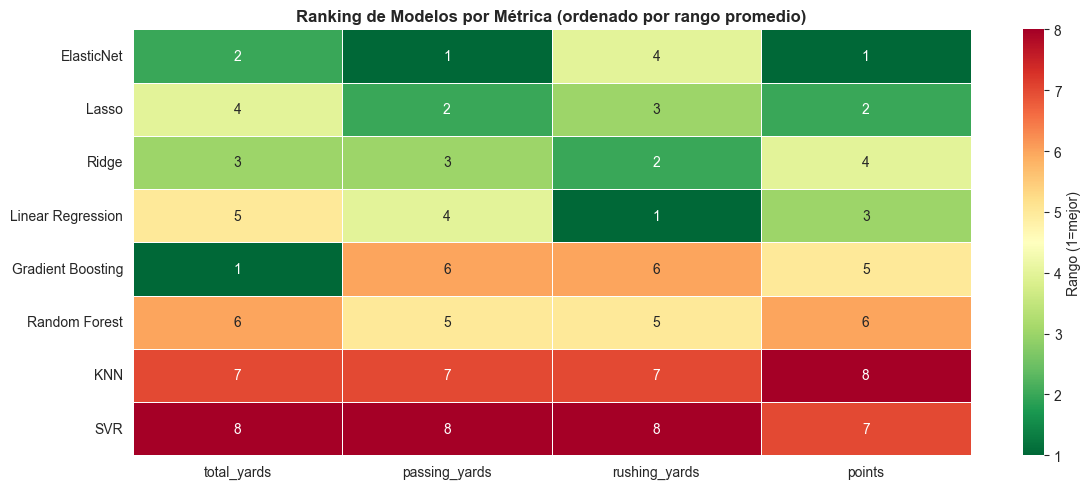

In [28]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(rank_df.drop(columns='avg_rank'), annot=True, fmt='.0f',
            cmap='RdYlGn_r', ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Rango (1=mejor)'})
ax.set_title('Ranking de Modelos por Métrica (ordenado por rango promedio)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [29]:
best_models = {}
print("MEJOR MODELO POR MÉTRICA (menor MAE en test set)")
print("=" * 60)
for metric_name in METRICS:
    best_name = min(comparison_results[metric_name],
                    key=lambda m: comparison_results[metric_name][m]['mae'])
    best_mae  = comparison_results[metric_name][best_name]['mae']
    best_cv   = comparison_results[metric_name][best_name]['cv_mae']
    best_r2   = comparison_results[metric_name][best_name]['r2']
    best_models[metric_name] = best_name
    print(f"  {metric_name:<15} → {best_name:<22}  MAE:{best_mae:.2f}  CV-MAE:{best_cv:.2f}  R²:{best_r2:.3f}")

print()
print("Modelo ElasticNet (actual) para referencia:")
for metric_name in METRICS:
    en = comparison_results[metric_name]['ElasticNet']
    print(f"  {metric_name:<15}   ElasticNet  MAE:{en['mae']:.2f}  CV-MAE:{en['cv_mae']:.2f}  R²:{en['r2']:.3f}")

MEJOR MODELO POR MÉTRICA (menor MAE en test set)
  total_yards     → Gradient Boosting       MAE:45.25  CV-MAE:49.98  R²:0.488
  passing_yards   → ElasticNet              MAE:40.20  CV-MAE:44.22  R²:0.397
  rushing_yards   → Linear Regression       MAE:27.25  CV-MAE:28.51  R²:0.480
  points          → ElasticNet              MAE:5.76  CV-MAE:6.00  R²:0.386

Modelo ElasticNet (actual) para referencia:
  total_yards       ElasticNet  MAE:45.28  CV-MAE:49.43  R²:0.512
  passing_yards     ElasticNet  MAE:40.20  CV-MAE:44.22  R²:0.397
  rushing_yards     ElasticNet  MAE:27.50  CV-MAE:28.48  R²:0.480
  points            ElasticNet  MAE:5.76  CV-MAE:6.00  R²:0.386


---
## 10. Predicciones con el Mejor Modelo por Métrica

La lógica de predicción es idéntica al sistema original:
- Estadísticas del equipo antes del juego
- Ajuste defensivo con factor del oponente
- Ventaja de local (+2.8 pts, +8 yds)

La diferencia es que cada métrica usa el modelo con menor MAE en lugar de siempre ElasticNet.

In [30]:
ADJUSTMENT_FACTORS = {'total_yards': 0.18, 'passing_yards': 0.22, 'rushing_yards': 0.20, 'points': 0.15}

def get_team_current_stats(team, target_week, season=2025):
    if target_week == 1:
        return team_2024_stats.get(team)
    t_data = dfT_features[
        (dfT_features['team'] == team) &
        (dfT_features['season'] == season) &
        (dfT_features['week'] < target_week)
    ].tail(1)
    return t_data.iloc[0] if not t_data.empty else team_2024_stats.get(team)

def get_team_defensive_stats(team, target_week, season=2025):
    if target_week == 1:
        def_data = dfR[(dfR['team'] == team) & (dfR['season'] == 2024)].tail(1)
    else:
        def_data = dfR[
            (dfR['team'] == team) & (dfR['season'] == season) & (dfR['week'] < target_week)
        ].tail(1)
        if def_data.empty:
            def_data = dfR[(dfR['team'] == team) & (dfR['season'] == 2024)].tail(1)
    return def_data if not def_data.empty else None

def build_features(team_stats, opp_def_row, is_home, week, season):
    d = opp_def_row.iloc[0] if hasattr(opp_def_row, 'iloc') else opp_def_row
    return {
        'season': season, 'week': week, 'is_home': is_home,
        'team_points_avg_3':       team_stats.get('points_avg_3', 24),
        'team_points_avg_4':       team_stats.get('points_avg_4', 24),
        'team_points_avg_6':       team_stats.get('points_avg_6', 24),
        'team_total_yards_avg_3':  team_stats.get('total_yards_avg_3', 350),
        'team_total_yards_avg_4':  team_stats.get('total_yards_avg_4', 350),
        'team_total_yards_avg_6':  team_stats.get('total_yards_avg_6', 350),
        'team_passing_yards_avg_4': team_stats.get('passing_yards_avg_4', 230),
        'team_rushing_yards_avg_4': team_stats.get('rushing_yards_avg_4', 120),
        'team_points_std_4':       team_stats.get('points_std_4', 7),
        'team_total_yards_std_4':  team_stats.get('total_yards_std_4', 50),
        'team_points_trend_4':     team_stats.get('points_trend_4', 0),
        'team_total_yards_trend_4': team_stats.get('total_yards_trend_4', 0),
        'team_off_efficiency':     team_stats.get('offensive_efficiency', 0.07),
        'team_pass_rush_ratio':    team_stats.get('pass_rush_ratio', 2.0),
        'team_recent_points':      team_stats.get('recent_points_avg', 24),
        'opp_def_total_rank':      d.get('op_total_yards_rank', 16),
        'opp_def_passing_rank':    d.get('op_passing_yards_rank', 16),
        'opp_def_rushing_rank':    d.get('op_rushing_yards_rank', 16),
        'opp_def_points_rank':     d.get('op_points_rank', 16),
        'opp_def_total_factor':    d.get('op_total_yards_factor', 0.5),
        'opp_def_points_factor':   d.get('op_points_factor', 0.5)
    }

def predict_game_best(away_team, home_team, week, season=2025):
    away_stats = get_team_current_stats(away_team, week, season)
    home_stats = get_team_current_stats(home_team, week, season)
    if away_stats is None or home_stats is None:
        return None

    away_def = get_team_defensive_stats(away_team, week, season)
    home_def = get_team_defensive_stats(home_team, week, season)
    if away_def is None or home_def is None:
        return None

    away_feats = build_features(away_stats, home_def, 0, week, season)
    home_feats = build_features(home_stats, away_def, 1, week, season)

    away_preds = {}
    home_preds = {}

    for metric in ['total_yards', 'passing_yards', 'rushing_yards', 'points']:
        model, scaler = trained_models[metric][best_models[metric]]
        factor = ADJUSTMENT_FACTORS[metric]

        away_X   = pd.DataFrame([away_feats])[FEATURE_COLS]
        away_raw = model.predict(scaler.transform(away_X))[0]
        def_f    = away_feats['opp_def_total_factor'] if metric != 'points' else away_feats['opp_def_points_factor']
        eff_adj  = (away_feats['team_off_efficiency'] - 0.07) * 0.1
        away_preds[metric] = max(0, away_raw + away_raw * ((def_f - 0.5) * factor + eff_adj))

        home_X   = pd.DataFrame([home_feats])[FEATURE_COLS]
        home_raw = model.predict(scaler.transform(home_X))[0]
        def_f    = home_feats['opp_def_total_factor'] if metric != 'points' else home_feats['opp_def_points_factor']
        eff_adj  = (home_feats['team_off_efficiency'] - 0.07) * 0.1
        home_final = home_raw + home_raw * ((def_f - 0.5) * factor + eff_adj)
        if metric == 'points':
            home_final += 2.8
        elif metric == 'total_yards':
            home_final += 8
        home_preds[metric] = max(0, home_final)

    diff   = abs(home_preds['points'] - away_preds['points'])
    winner = 'home' if home_preds['points'] > away_preds['points'] else 'away'
    return {
        'away_team': away_team, 'home_team': home_team, 'week': week, 'season': season,
        'away_predictions': away_preds, 'home_predictions': home_preds,
        'predicted_winner': winner,
        'point_differential': diff,
        'confidence': min(diff / 16.0, 1.0)
    }

In [31]:
next_week  = max_available_week + 1 if max_available_week > 0 else 1
week_games = dfS[(dfS['season'] == current_season) & (dfS['week'] == next_week)]

print(f"PREDICCIONES SEMANA {next_week} — TEMPORADA {current_season}")
print(f"Modelos usados: {best_models}")
print(f"Juegos encontrados: {len(week_games)}")
print("=" * 75)

predictions = []
for _, game in week_games.iterrows():
    pred = predict_game_best(game['away_team'], game['home_team'], next_week, current_season)
    if pred:
        predictions.append(pred)
        winner_team = pred['home_team'] if pred['predicted_winner'] == 'home' else pred['away_team']
        print(
            f"  {pred['away_team']:>4s} @ {pred['home_team']:<4s} | "
            f"Score: {pred['away_predictions']['points']:.1f} - {pred['home_predictions']['points']:.1f} | "
            f"Ganador: {winner_team} | Confianza: {pred['confidence']:.0%}"
        )

print(f"\nTotal predicciones: {len(predictions)}")

PREDICCIONES SEMANA 18 — TEMPORADA 2025
Modelos usados: {'total_yards': 'Gradient Boosting', 'passing_yards': 'ElasticNet', 'rushing_yards': 'Linear Regression', 'points': 'ElasticNet'}
Juegos encontrados: 16
    NO @ ATL  | Score: 21.9 - 23.7 | Ganador: ATL | Confianza: 11%
   NYJ @ BUF  | Score: 16.1 - 34.4 | Ganador: BUF | Confianza: 100%


   DET @ CHI  | Score: 29.2 - 31.6 | Ganador: CHI | Confianza: 15%
   CLE @ CIN  | Score: 21.4 - 24.3 | Ganador: CIN | Confianza: 18%
   LAC @ DEN  | Score: 20.8 - 24.2 | Ganador: DEN | Confianza: 22%


   IND @ HOU  | Score: 15.1 - 32.8 | Ganador: HOU | Confianza: 100%


   TEN @ JAX  | Score: 17.4 - 28.8 | Ganador: JAX | Confianza: 72%
    KC @ LV   | Score: 24.6 - 21.6 | Ganador: KC | Confianza: 19%
    GB @ MIN  | Score: 15.4 - 31.7 | Ganador: MIN | Confianza: 100%
   MIA @ NE   | Score: 16.7 - 35.6 | Ganador: NE | Confianza: 100%


   DAL @ NYG  | Score: 22.6 - 34.0 | Ganador: NYG | Confianza: 71%
   ARI @ LAR  | Score: 22.9 - 37.1 | Ganador: LAR | Confianza: 89%
   BAL @ PIT  | Score: 22.4 - 28.5 | Ganador: PIT | Confianza: 38%
   SEA @ SF   | Score: 29.2 - 27.4 | Ganador: SEA | Confianza: 11%
   CAR @ TB   | Score: 22.9 - 25.8 | Ganador: TB | Confianza: 18%


   WSH @ PHI  | Score: 15.0 - 33.3 | Ganador: PHI | Confianza: 100%

Total predicciones: 16


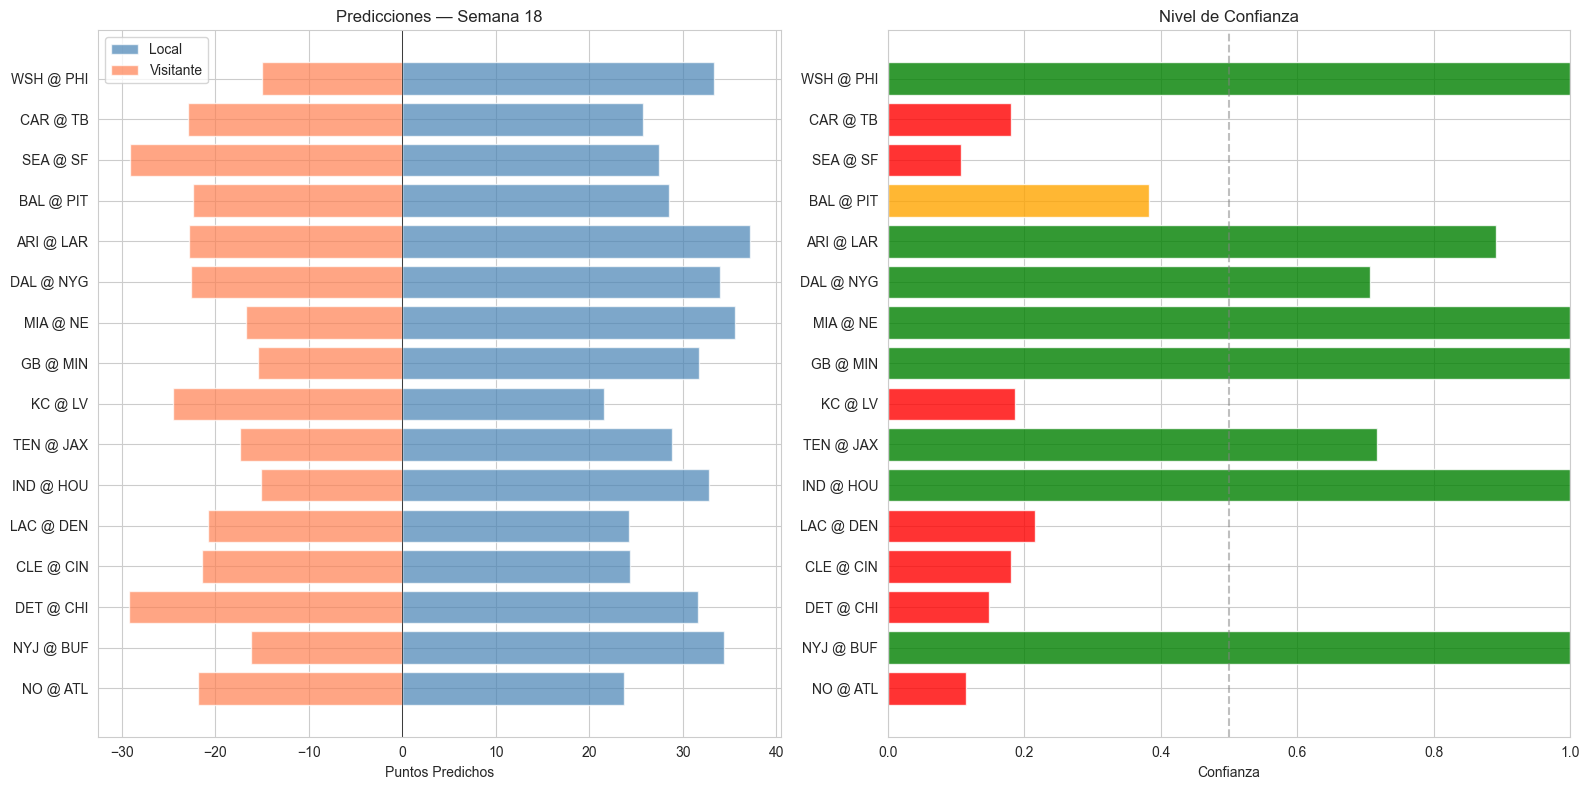

In [32]:
if predictions:
    pred_df = pd.DataFrame([{
        'matchup':    f"{p['away_team']} @ {p['home_team']}",
        'away_pts':   p['away_predictions']['points'],
        'home_pts':   p['home_predictions']['points'],
        'confidence': p['confidence'],
        'winner':     p['home_team'] if p['predicted_winner'] == 'home' else p['away_team']
    } for p in predictions])

    fig, axes = plt.subplots(1, 2, figsize=(16, max(6, len(predictions) * 0.5)))
    y_pos = range(len(pred_df))

    axes[0].barh(y_pos, pred_df['home_pts'], alpha=0.7, label='Local', color='steelblue')
    axes[0].barh(y_pos, -pred_df['away_pts'], alpha=0.7, label='Visitante', color='coral')
    axes[0].set_yticks(y_pos)
    axes[0].set_yticklabels(pred_df['matchup'])
    axes[0].set_xlabel('Puntos Predichos')
    axes[0].set_title(f'Predicciones — Semana {next_week}')
    axes[0].axvline(x=0, color='black', linewidth=0.5)
    axes[0].legend()

    colors = ['green' if c > 0.5 else 'orange' if c > 0.3 else 'red' for c in pred_df['confidence']]
    axes[1].barh(y_pos, pred_df['confidence'], color=colors, alpha=0.8)
    axes[1].set_yticks(y_pos)
    axes[1].set_yticklabels(pred_df['matchup'])
    axes[1].set_xlabel('Confianza')
    axes[1].set_title('Nivel de Confianza')
    axes[1].set_xlim(0, 1)
    axes[1].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

---
## Resumen

| Componente | Sistema Original | Este Análisis |
|------------|-----------------|---------------|
| **Modelo** | ElasticNet fijo | Mejor modelo por métrica |
| **Modelos evaluados** | 1 | 8 |
| **Evaluación** | Train/test split | Split + 5-fold CV |
| **Métricas** | MAE, RMSE, R² | MAE, RMSE, R², CV-MAE |
| **Scaler** | RobustScaler | RobustScaler (Pipeline) |
| **Features** | 24 | 24 (mismas) |
| **Datos** | 2023-2024 | 2023-2024 (mismos) |

### Modelos evaluados

| Modelo | Ventaja | Desventaja |
|--------|---------|------------|
| Linear Regression | Interpretable, rápido | Sin regularización, overfitting |
| Ridge | Maneja multicolinealidad (L2) | No elimina features |
| Lasso | Selección automática de features (L1) | Puede ser inestable |
| ElasticNet | Combina L1+L2, robusto | Menos flexible que ensembles |
| Random Forest | Captura no-linealidades, robusto | Más lento, menos interpretable |
| Gradient Boosting | Alta precisión, flexible | Requiere tuning, lento |
| KNN | Simple, sin supuestos | Lento en inferencia, sensible a escala |
| SVR | Bueno con pocos datos | Lento, kernel RBF requiere tuning |